In [ ]:
!pip install pdfplumber

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.1/68.1 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 68.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 97.1 MB/s eta 0:00:00


In [ ]:
import pdfplumber
import re
from datetime import datetime
import pandas as pd
from typing import List, Dict, Optional
import warnings
warnings.filterwarnings('ignore')

class TransactionExtractor:
    """
    Extract transaction details from PDFs with the structure shown in the screenshot:
    - Date and Time
    - Recipient (Paid to / Received from)
    - Transaction Type (DEBIT/CREDIT)
    - Amount
    - Transaction ID and UTR (optional)
    """

    def __init__(self, pdf_path: str):
        self.pdf_path = pdf_path
        self.transactions = []

    def extract_transactions(self) -> pd.DataFrame:
        """
        Main method to extract all transactions from PDF
        """
        print(f"\n{'='*60}")
        print(f"Extracting transactions from: {self.pdf_path}")
        print('='*60)

        try:
            with pdfplumber.open(self.pdf_path) as pdf:
                for page_num, page in enumerate(pdf.pages, 1):
                    print(f"\n📄 Processing Page {page_num}...")

                    # Extract text from page
                    text = page.extract_text()
                    if not text:
                        print(f"  ⚠️ No text found on page {page_num}")
                        continue

                    # Split text into lines
                    lines = text.split('\n')

                    # Process the page to find transactions
                    page_transactions = self._process_page(lines, page_num)

                    if page_transactions:
                        self.transactions.extend(page_transactions)
                        print(f"  ✅ Found {len(page_transactions)} transaction(s) on page {page_num}")

            # Create DataFrame
            df = self._create_dataframe()

            # Print summary
            self._print_summary(df)

            return df

        except Exception as e:
            print(f"❌ Error extracting transactions: {str(e)}")
            return pd.DataFrame()

    def _process_page(self, lines: List[str], page_num: int) -> List[Dict]:
        """
        Process a page's lines to extract transaction blocks
        """
        transactions = []
        i = 0

        while i < len(lines):
            line = lines[i].strip()

            # Look for transaction start (usually contains date)
            if self._looks_like_date_line(line):
                transaction = self._extract_transaction_block(lines, i, page_num)
                if transaction:
                    transactions.append(transaction)
                    # Print each transaction as it's found
                    self._print_transaction(transaction)

                    # Skip ahead to avoid reprocessing
                    i += 4  # Transaction usually spans 3-4 lines
                else:
                    i += 1
            else:
                i += 1

        return transactions

    def _extract_transaction_block(self, lines: List[str], start_idx: int, page_num: int) -> Optional[Dict]:
        """
        Extract a complete transaction block starting at start_idx
        """
        try:
            transaction = {
                'page_number': page_num,
                'raw_lines': []
            }

            # Line 1: Date and main transaction info
            line1 = lines[start_idx].strip()
            transaction['raw_lines'].append(line1)

            # Extract date and time from line 1
            date_time = self._extract_date_time(line1)
            if date_time:
                transaction.update(date_time)

            # Extract recipient and type from line 1
            recipient_info = self._extract_recipient_and_type(line1)
            if recipient_info:
                transaction.update(recipient_info)

            # Extract amount from line 1
            amount = self._extract_amount(line1)
            if amount:
                transaction['amount'] = amount

            # Line 2: Transaction ID and UTR (if available)
            if start_idx + 1 < len(lines):
                line2 = lines[start_idx + 1].strip()
                if line2 and ('Transaction ID' in line2 or 'UTR' in line2):
                    transaction['raw_lines'].append(line2)
                    tx_info = self._extract_transaction_ids(line2)
                    transaction.update(tx_info)

            # Line 3: Additional info (like "Paid by XXXXXXX")
            if start_idx + 2 < len(lines):
                line3 = lines[start_idx + 2].strip()
                if line3 and 'Paid by' in line3:
                    transaction['raw_lines'].append(line3)
                    transaction['paid_by'] = line3.replace('Paid by', '').strip()

            return transaction

        except Exception as e:
            print(f"Error extracting transaction block: {e}")
            return None

    def _looks_like_date_line(self, line: str) -> bool:
        """
        Check if line contains a date (like "Feb 13, 2026")
        """
        date_patterns = [
            r'[A-Z][a-z]{2}\s+\d{1,2},\s+\d{4}',  # Feb 13, 2026
            r'\d{1,2}\s+[A-Z][a-z]{2}\s+\d{4}',   # 13 Feb 2026
            r'\d{1,2}[/-]\d{1,2}[/-]\d{2,4}',     # 13/02/2026 or 13-02-2026
        ]

        for pattern in date_patterns:
            if re.search(pattern, line):
                return True
        return False

    def _extract_date_time(self, line: str) -> Dict:
        """
        Extract date and time from line
        """
        result = {}

        # Extract date (e.g., "Feb 13, 2026")
        date_match = re.search(r'([A-Z][a-z]{2}\s+\d{1,2},\s+\d{4})', line)
        if date_match:
            result['date'] = date_match.group(1)

            # Try to parse date for sorting
            try:
                parsed_date = datetime.strptime(date_match.group(1), '%b %d, %Y')
                result['parsed_date'] = parsed_date
            except:
                pass

        # Extract time (e.g., "01:20 pm")
        time_match = re.search(r'(\d{1,2}:\d{2}\s*[ap]m)', line.lower())
        if time_match:
            result['time'] = time_match.group(1)

        return result

    def _extract_recipient_and_type(self, line: str) -> Dict:
        """
        Extract recipient and transaction type (DEBIT/CREDIT)
        """
        result = {}

        # Find transaction type
        if 'DEBIT' in line:
            result['type'] = 'DEBIT'
        elif 'CREDIT' in line:
            result['type'] = 'CREDIT'
        elif 'Paid to' in line:
            result['type'] = 'DEBIT'
        elif 'Received from' in line:
            result['type'] = 'CREDIT'

        # Extract recipient
        # Pattern: "Paid to [Recipient Name]"
        recipient_match = re.search(r'Paid to\s+(.+?)(?:\s+DEBIT|\s+CREDIT|$)', line)
        if recipient_match:
            result['recipient'] = recipient_match.group(1).strip()
        else:
            # Try alternative pattern
            recipient_match = re.search(r'Received from\s+(.+?)(?:\s+DEBIT|\s+CREDIT|$)', line)
            if recipient_match:
                result['recipient'] = recipient_match.group(1).strip()

        return result

    def _extract_amount(self, line: str) -> Optional[float]:
        """
        Extract amount from line (handles ₹ symbol)
        """
        # Pattern for amount with ₹ symbol
        amount_match = re.search(r'[₹]\s*(\d+(?:,\d+)*(?:\.\d{2})?)', line)
        if amount_match:
            amount_str = amount_match.group(1).replace(',', '')
            try:
                return float(amount_str)
            except:
                pass

        # Pattern for amount without ₹ symbol but with decimal
        amount_match = re.search(r'(\d+(?:,\d+)*(?:\.\d{2})?)\s*$', line)
        if amount_match:
            amount_str = amount_match.group(1).replace(',', '')
            try:
                return float(amount_str)
            except:
                pass

        return None

    def _extract_transaction_ids(self, line: str) -> Dict:
        """
        Extract Transaction ID and UTR number
        """
        result = {}

        # Extract Transaction ID
        tx_match = re.search(r'Transaction ID\s+(\S+)', line)
        if tx_match:
            result['transaction_id'] = tx_match.group(1)

        # Extract UTR Number
        utr_match = re.search(r'UTR No\.?\s+(\S+)', line)
        if utr_match:
            result['utr_number'] = utr_match.group(1)

        return result

    def _print_transaction(self, transaction: Dict):
        """
        Print individual transaction details
        """
        print(f"\n  {'─'*40}")
        print(f"  📅 Date: {transaction.get('date', 'N/A')} {transaction.get('time', '')}")
        print(f"  👤 Recipient: {transaction.get('recipient', 'N/A')}")
        print(f"  💳 Type: {transaction.get('type', 'N/A')}")
        print(f"  💰 Amount: ₹{transaction.get('amount', 0):,.2f}")

        if transaction.get('transaction_id'):
            print(f"  🆔 Transaction ID: {transaction['transaction_id']}")
        if transaction.get('utr_number'):
            print(f"  🔢 UTR: {transaction['utr_number']}")
        if transaction.get('paid_by'):
            print(f"  💳 Paid by: {transaction['paid_by']}")

    def _create_dataframe(self) -> pd.DataFrame:
        """
        Create pandas DataFrame from extracted transactions
        """
        if not self.transactions:
            return pd.DataFrame()

        df = pd.DataFrame(self.transactions)

        # Select and order relevant columns
        columns = ['date', 'time', 'recipient', 'type', 'amount',
                  'transaction_id', 'utr_number', 'paid_by', 'page_number']

        # Keep only columns that exist
        available_cols = [col for col in columns if col in df.columns]
        df = df[available_cols]

        # Sort by date if available
        if 'parsed_date' in df.columns:
            df = df.sort_values('parsed_date')
        elif 'date' in df.columns:
            df = df.sort_values('date')

        return df

    def _print_summary(self, df: pd.DataFrame):
        """
        Print summary of all extracted transactions
        """
        if df.empty:
            print("\n❌ No transactions found in the PDF")
            return

        print(f"\n{'='*60}")
        print(f"📊 EXTRACTION SUMMARY")
        print(f"{'='*60}")
        print(f"Total transactions found: {len(df)}")

        # Calculate totals
        if 'amount' in df.columns and 'type' in df.columns:
            total_debit = df[df['type'] == 'DEBIT']['amount'].sum()
            total_credit = df[df['type'] == 'CREDIT']['amount'].sum()

            print(f"\n💰 Financial Summary:")
            print(f"  Total Debit:  ₹{total_debit:,.2f}")
            print(f"  Total Credit: ₹{total_credit:,.2f}")
            print(f"  Net Flow:     ₹{total_credit - total_debit:,.2f}")

        # Date range
        if 'date' in df.columns:
            dates = df['date'].dropna()
            if not dates.empty:
                print(f"\n📅 Date Range: {dates.min()} to {dates.max()}")

        print(f"\n📋 First 3 transactions:")
        print(df.head(3).to_string(index=False))

        # Save to CSV option
        print(f"\n💾 To save to CSV: df.to_csv('transactions.csv', index=False)")

# Function to extract from multiple PDFs
def extract_from_multiple_pdfs(pdf_paths: List[str]) -> pd.DataFrame:
    """
    Extract transactions from multiple PDF files
    """
    all_transactions = []

    for pdf_path in pdf_paths:
        extractor = TransactionExtractor(pdf_path)
        df = extractor.extract_transactions()
        if not df.empty:
            df['source_file'] = pdf_path
            all_transactions.append(df)

    if all_transactions:
        combined_df = pd.concat(all_transactions, ignore_index=True)
        return combined_df
    else:
        return pd.DataFrame()

# Main execution
if __name__ == "__main__":
    # Example usage
    pdf_file = "/content/PhonePe_Statement_Aug2025_Sept2025.pdf"  # Replace with your PDF file

    try:
        # Extract transactions
        extractor = TransactionExtractor(pdf_file)
        df = extractor.extract_transactions()

        if not df.empty:
            # Additional analysis
            print(f"\n{'='*60}")
            print("🔍 ADDITIONAL ANALYSIS")
            print('='*60)

            # Group by recipient
            if 'recipient' in df.columns and 'amount' in df.columns:
                print("\n💰 Top Recipients (by total amount):")
                recipient_totals = df.groupby('recipient')['amount'].sum().sort_values(ascending=False).head(5)
                for recipient, amount in recipient_totals.items():
                    print(f"  {recipient}: ₹{amount:,.2f}")

            # Transactions by type
            if 'type' in df.columns:
                print("\n📊 Transactions by Type:")
                type_counts = df['type'].value_counts()
                for t_type, count in type_counts.items():
                    print(f"  {t_type}: {count} transactions")

            # Save to CSV
            csv_file = pdf_file.replace('.pdf', '_transactions.csv')
            df.to_csv(csv_file, index=False)
            print(f"\n💾 Saved to: {csv_file}")

            # Save to Excel with formatting
            excel_file = pdf_file.replace('.pdf', '_transactions.xlsx')
            with pd.ExcelWriter(excel_file, engine='openpyxl') as writer:
                df.to_excel(writer, sheet_name='Transactions', index=False)

                # Auto-adjust column widths
                worksheet = writer.sheets['Transactions']
                for column in worksheet.columns:
                    max_length = 0
                    column_letter = column[0].column_letter
                    for cell in column:
                        try:
                            if len(str(cell.value)) > max_length:
                                max_length = len(str(cell.value))
                        except:
                            pass
                    adjusted_width = min(max_length + 2, 50)
                    worksheet.column_dimensions[column_letter].width = adjusted_width

            print(f"💾 Saved to: {excel_file}")

    except FileNotFoundError:
        print(f"❌ File '{pdf_file}' not found. Please provide a valid PDF path.")
    except Exception as e:
        print(f"❌ An error occurred: {str(e)}")


Extracting transactions from: /content/PhonePe_Statement_Aug2025_Sept2025.pdf

📄 Processing Page 1...



📄 Processing Page 2...

📄 Processing Page 3...

📄 Processing Page 4...

📄 Processing Page 5...

📄 Processing Page 6...

📄 Processing Page 7...

📄 Processing Page 8...

📄 Processing Page 9...

📄 Processing Page 10...

📄 Processing Page 11...

📄 Processing Page 12...

📄 Processing Page 13...

📄 Processing Page 14...

📄 Processing Page 15...

📄 Processing Page 16...

  ────────────────────────────────────────
  📅 Date: Aug 31, 2025 
  👤 Recipient: ARCHI CHOUDHARY
  💳 Type: CREDIT
  💰 Amount: ₹12,000.00
  🆔 Transaction ID: T2508312314305712044706

  ────────────────────────────────────────
  📅 Date: Aug 31, 2025 
  👤 Recipient: Manirul Guava Stall
  💳 Type: DEBIT
  💰 Amount: ₹22.00
  🆔 Transaction ID: T2508312049392478053102

  ────────────────────────────────────────
  📅 Date: Aug 31, 2025 
  👤 Recipient: Chakraborty Fruits Shop
  💳 Type: DEBIT
  💰 Amount: ₹40.00
  🆔 Transaction ID: T2508312046539588441101
  ✅ Found 3 transaction(s) on page 16

📄 Processing Page 17...

  ────────────────

In [ ]:
import pdfplumber
import re
from datetime import datetime
import pandas as pd
from typing import List, Dict, Optional
import warnings
warnings.filterwarnings('ignore')

class TransactionExtractor:
    """
    Extract transaction details from PDFs with the structure shown in the screenshot:
    - Date and Time
    - Recipient (Paid to / Received from)
    - Transaction Type (DEBIT/CREDIT)
    - Amount
    - Transaction ID and UTR (optional)
    """

    def __init__(self, pdf_path: str):
        self.pdf_path = pdf_path
        self.transactions = []

    def extract_transactions(self) -> pd.DataFrame:
        """
        Main method to extract all transactions from PDF
        """
        print(f"\n{'='*60}")
        print(f"Extracting transactions from: {self.pdf_path}")
        print('='*60)

        try:
            with pdfplumber.open(self.pdf_path) as pdf:
                for page_num, page in enumerate(pdf.pages, 1):
                    print(f"\n📄 Processing Page {page_num}...")

                    # Extract text from page
                    text = page.extract_text()
                    if not text:
                        print(f"  ⚠️ No text found on page {page_num}")
                        continue

                    # Split text into lines
                    lines = text.split('\n')

                    # Process the page to find transactions
                    page_transactions = self._process_page(lines, page_num)

                    if page_transactions:
                        self.transactions.extend(page_transactions)
                        print(f"  ✅ Found {len(page_transactions)} transaction(s) on page {page_num}")

            # Create DataFrame
            df = self._create_dataframe()

            # Print summary
            self._print_summary(df)

            return df

        except Exception as e:
            print(f"❌ Error extracting transactions: {str(e)}")
            return pd.DataFrame()

    def _process_page(self, lines: List[str], page_num: int) -> List[Dict]:
        """
        Process a page's lines to extract transaction blocks
        """
        transactions = []
        i = 0

        while i < len(lines):
            line = lines[i].strip()

            # Look for transaction start (usually contains date)
            if self._looks_like_date_line(line):
                transaction = self._extract_transaction_block(lines, i, page_num)
                if transaction:
                    transactions.append(transaction)
                    # Print each transaction as it's found
                    self._print_transaction(transaction)

                    # Skip ahead to avoid reprocessing
                    i += 4  # Transaction usually spans 3-4 lines
                else:
                    i += 1
            else:
                i += 1

        return transactions

    def _extract_transaction_block(self, lines: List[str], start_idx: int, page_num: int) -> Optional[Dict]:
        """
        Extract a complete transaction block starting at start_idx
        """
        try:
            transaction = {
                'page_number': page_num,
                'raw_lines': []
            }

            # Line 1: Date and main transaction info
            line1 = lines[start_idx].strip()
            transaction['raw_lines'].append(line1)

            # Extract date from line 1
            date_time = self._extract_date_time(line1)
            if date_time:
                transaction.update(date_time)

            # Extract recipient and type from line 1
            recipient_info = self._extract_recipient_and_type(line1)
            if recipient_info:
                transaction.update(recipient_info)

            # Extract amount from line 1
            amount = self._extract_amount(line1)
            if amount:
                transaction['amount'] = amount

            # Look for time in the next few lines if not found in line1
            if 'time' not in transaction:
                # Check next line for time
                if start_idx + 1 < len(lines):
                    next_line = lines[start_idx + 1].strip()
                    time_match = re.search(r'(\d{1,2}:\d{2}\s*[ap]m)', next_line.lower())
                    if time_match:
                        transaction['time'] = time_match.group(1)
                        transaction['raw_lines'].append(next_line)

                # If still not found, check the line after that
                if 'time' not in transaction and start_idx + 2 < len(lines):
                    next_next_line = lines[start_idx + 2].strip()
                    time_match = re.search(r'(\d{1,2}:\d{2}\s*[ap]m)', next_next_line.lower())
                    if time_match:
                        transaction['time'] = time_match.group(1)
                        transaction['raw_lines'].append(next_next_line)

            # Line containing Transaction ID and UTR (if available)
            # Check all subsequent lines for transaction IDs
            for offset in [1, 2, 3]:
                if start_idx + offset < len(lines):
                    check_line = lines[start_idx + offset].strip()
                    if check_line and ('Transaction ID' in check_line or 'UTR' in check_line):
                        if check_line not in transaction['raw_lines']:
                            transaction['raw_lines'].append(check_line)
                        tx_info = self._extract_transaction_ids(check_line)
                        transaction.update(tx_info)
                        break

            # Line with "Paid by" info (if available)
            for offset in [1, 2, 3]:
                if start_idx + offset < len(lines):
                    check_line = lines[start_idx + offset].strip()
                    if check_line and 'Paid by' in check_line:
                        if check_line not in transaction['raw_lines']:
                            transaction['raw_lines'].append(check_line)
                        transaction['paid_by'] = check_line.replace('Paid by', '').strip()
                        break

            return transaction

        except Exception as e:
            print(f"Error extracting transaction block: {e}")
            return None

    def _looks_like_date_line(self, line: str) -> bool:
        """
        Check if line contains a date (like "Feb 13, 2026")
        """
        date_patterns = [
            r'[A-Z][a-z]{2}\s+\d{1,2},\s+\d{4}',  # Feb 13, 2026
            r'\d{1,2}\s+[A-Z][a-z]{2}\s+\d{4}',   # 13 Feb 2026
            r'\d{1,2}[/-]\d{1,2}[/-]\d{2,4}',     # 13/02/2026 or 13-02-2026
        ]

        for pattern in date_patterns:
            if re.search(pattern, line):
                return True
        return False

    def _extract_date_time(self, line: str) -> Dict:
        """
        Extract date from line (time extraction moved to separate logic)
        """
        result = {}

        # Extract date (e.g., "Feb 13, 2026")
        date_match = re.search(r'([A-Z][a-z]{2}\s+\d{1,2},\s+\d{4})', line)
        if date_match:
            result['date'] = date_match.group(1)

            # Try to parse date for sorting
            try:
                parsed_date = datetime.strptime(date_match.group(1), '%b %d, %Y')
                result['parsed_date'] = parsed_date
            except:
                pass

        # Also check for time in the same line (just in case)
        time_match = re.search(r'(\d{1,2}:\d{2}\s*[ap]m)', line.lower())
        if time_match:
            result['time'] = time_match.group(1)

        return result

    def _extract_recipient_and_type(self, line: str) -> Dict:
        """
        Extract recipient and transaction type (DEBIT/CREDIT)
        """
        result = {}

        # Find transaction type
        if 'DEBIT' in line:
            result['type'] = 'DEBIT'
        elif 'CREDIT' in line:
            result['type'] = 'CREDIT'
        elif 'Paid to' in line:
            result['type'] = 'DEBIT'
        elif 'Received from' in line:
            result['type'] = 'CREDIT'

        # Extract recipient
        # Pattern: "Paid to [Recipient Name]"
        recipient_match = re.search(r'Paid to\s+(.+?)(?:\s+DEBIT|\s+CREDIT|$)', line)
        if recipient_match:
            result['recipient'] = recipient_match.group(1).strip()
        else:
            # Try alternative pattern
            recipient_match = re.search(r'Received from\s+(.+?)(?:\s+DEBIT|\s+CREDIT|$)', line)
            if recipient_match:
                result['recipient'] = recipient_match.group(1).strip()

        return result

    def _extract_amount(self, line: str) -> Optional[float]:
        """
        Extract amount from line (handles ₹ symbol)
        """
        # Pattern for amount with ₹ symbol
        amount_match = re.search(r'[₹]\s*(\d+(?:,\d+)*(?:\.\d{2})?)', line)
        if amount_match:
            amount_str = amount_match.group(1).replace(',', '')
            try:
                return float(amount_str)
            except:
                pass

        # Pattern for amount without ₹ symbol but with decimal
        amount_match = re.search(r'(\d+(?:,\d+)*(?:\.\d{2})?)\s*$', line)
        if amount_match:
            amount_str = amount_match.group(1).replace(',', '')
            try:
                return float(amount_str)
            except:
                pass

        return None

    def _extract_transaction_ids(self, line: str) -> Dict:
        """
        Extract Transaction ID and UTR number
        """
        result = {}

        # Extract Transaction ID
        tx_match = re.search(r'Transaction ID\s+(\S+)', line)
        if tx_match:
            result['transaction_id'] = tx_match.group(1)

        # Extract UTR Number
        utr_match = re.search(r'UTR No\.?\s+(\S+)', line)
        if utr_match:
            result['utr_number'] = utr_match.group(1)

        return result

    def _print_transaction(self, transaction: Dict):
        """
        Print individual transaction details
        """
        print(f"\n  {'─'*40}")
        print(f"  📅 Date: {transaction.get('date', 'N/A')} {transaction.get('time', '')}")
        print(f"  👤 Recipient: {transaction.get('recipient', 'N/A')}")
        print(f"  💳 Type: {transaction.get('type', 'N/A')}")
        print(f"  💰 Amount: ₹{transaction.get('amount', 0):,.2f}")

        if transaction.get('transaction_id'):
            print(f"  🆔 Transaction ID: {transaction['transaction_id']}")
        if transaction.get('utr_number'):
            print(f"  🔢 UTR: {transaction['utr_number']}")


    def _create_dataframe(self) -> pd.DataFrame:
        """
        Create pandas DataFrame from extracted transactions
        """
        if not self.transactions:
            return pd.DataFrame()

        df = pd.DataFrame(self.transactions)

        # Select and order relevant columns
        columns = ['date', 'time', 'recipient', 'type', 'amount',
                  'transaction_id', 'utr_number']

        # Keep only columns that exist
        available_cols = [col for col in columns if col in df.columns]
        df = df[available_cols]

        # Sort by date if available
        if 'parsed_date' in df.columns:
            df = df.sort_values('parsed_date')
        elif 'date' in df.columns:
            df = df.sort_values('date')

        return df

    def _print_summary(self, df: pd.DataFrame):
        """
        Print summary of all extracted transactions
        """
        if df.empty:
            print("\n❌ No transactions found in the PDF")
            return

        print(f"\n{'='*60}")
        print(f"📊 EXTRACTION SUMMARY")
        print(f"{'='*60}")
        print(f"Total transactions found: {len(df)}")

        # Calculate totals
        if 'amount' in df.columns and 'type' in df.columns:
            total_debit = df[df['type'] == 'DEBIT']['amount'].sum()
            total_credit = df[df['type'] == 'CREDIT']['amount'].sum()

            print(f"\n💰 Financial Summary:")
            print(f"  Total Debit:  ₹{total_debit:,.2f}")
            print(f"  Total Credit: ₹{total_credit:,.2f}")
            print(f"  Net Flow:     ₹{total_credit - total_debit:,.2f}")

        # Date range
        if 'date' in df.columns:
            dates = df['date'].dropna()
            if not dates.empty:
                print(f"\n📅 Date Range: {dates.min()} to {dates.max()}")

        print(f"\n📋 First 3 transactions:")
        print(df.head(3).to_string(index=False))

        # Save to CSV option
        print(f"\n💾 To save to CSV: df.to_csv('transactions.csv', index=False)")

# Function to extract from multiple PDFs
def extract_from_multiple_pdfs(pdf_paths: List[str]) -> pd.DataFrame:
    """
    Extract transactions from multiple PDF files
    """
    all_transactions = []

    for pdf_path in pdf_paths:
        extractor = TransactionExtractor(pdf_path)
        df = extractor.extract_transactions()
        if not df.empty:
            df['source_file'] = pdf_path
            all_transactions.append(df)

    if all_transactions:
        combined_df = pd.concat(all_transactions, ignore_index=True)
        return combined_df
    else:
        return pd.DataFrame()

# Main execution
if __name__ == "__main__":
    # Example usage
    pdf_file = "/content/PhonePe_Statement_Jan2026_Feb2026.pdf"  # Replace with your PDF file

    try:
        # Extract transactions
        extractor = TransactionExtractor(pdf_file)
        df = extractor.extract_transactions()

        if not df.empty:
            # Additional analysis
            print(f"\n{'='*60}")
            print("🔍 ADDITIONAL ANALYSIS")
            print('='*60)

            # Group by recipient
            if 'recipient' in df.columns and 'amount' in df.columns:
                print("\n💰 Top Recipients (by total amount):")
                recipient_totals = df.groupby('recipient')['amount'].sum().sort_values(ascending=False).head(5)
                for recipient, amount in recipient_totals.items():
                    print(f"  {recipient}: ₹{amount:,.2f}")

            # Transactions by type
            if 'type' in df.columns:
                print("\n📊 Transactions by Type:")
                type_counts = df['type'].value_counts()
                for t_type, count in type_counts.items():
                    print(f"  {t_type}: {count} transactions")

            # Save to CSV
            csv_file = pdf_file.replace('.pdf', '_transactions.csv')
            df.to_csv(csv_file, index=False)
            print(f"\n💾 Saved to: {csv_file}")

            # Save to Excel with formatting
            excel_file = pdf_file.replace('.pdf', '_transactions.xlsx')
            with pd.ExcelWriter(excel_file, engine='openpyxl') as writer:
                df.to_excel(writer, sheet_name='Transactions', index=False)

                # Auto-adjust column widths
                worksheet = writer.sheets['Transactions']
                for column in worksheet.columns:
                    max_length = 0
                    column_letter = column[0].column_letter
                    for cell in column:
                        try:
                            if len(str(cell.value)) > max_length:
                                max_length = len(str(cell.value))
                        except:
                            pass
                    adjusted_width = min(max_length + 2, 50)
                    worksheet.column_dimensions[column_letter].width = adjusted_width

            print(f"💾 Saved to: {excel_file}")

    except FileNotFoundError:
        print(f"❌ File '{pdf_file}' not found. Please provide a valid PDF path.")
    except Exception as e:
        print(f"❌ An error occurred: {str(e)}")


Extracting transactions from: /content/PhonePe_Statement_Jan2026_Feb2026.pdf

📄 Processing Page 1...



  ────────────────────────────────────────
  📅 Date: Feb 13, 2026 01:20 pm
  👤 Recipient: Mamata saha
  💳 Type: DEBIT
  💰 Amount: ₹100.00
  🆔 Transaction ID: T2602131320397618093538

  ────────────────────────────────────────
  📅 Date: Feb 13, 2026 09:55 am
  👤 Recipient: Mr SURESH BASAK
  💳 Type: DEBIT
  💰 Amount: ₹73.00
  🆔 Transaction ID: T2602130955550497687083

  ────────────────────────────────────────
  📅 Date: Feb 12, 2026 08:09 pm
  👤 Recipient: mahidul fakir
  💳 Type: DEBIT
  💰 Amount: ₹65.00
  🆔 Transaction ID: T2602122009178807054954

  ────────────────────────────────────────
  📅 Date: Feb 12, 2026 07:39 pm
  👤 Recipient: DHANA DEVI
  💳 Type: DEBIT
  💰 Amount: ₹10.00
  🆔 Transaction ID: T2602121939049542982926

  ────────────────────────────────────────
  📅 Date: Feb 12, 2026 03:17 pm
  👤 Recipient: RATAN ROY
  💳 Type: DEBIT
  💰 Amount: ₹35.00
  🆔 Transaction ID: T2602121516597005923658

  ────────────────────────────────────────
  📅 Date: Feb 12, 2026 03:05 pm
  👤 Recipi

### For geting the unique recipient in a week and their frequency

In [ ]:

import pdfplumber
import re
from datetime import datetime
import pandas as pd
from typing import List, Dict, Optional
import warnings
warnings.filterwarnings('ignore')

class TransactionExtractor:
    """
    Extract transaction details from PDFs with the structure shown in the screenshot:
    - Date and Time
    - Recipient (Paid to / Received from)
    - Transaction Type (DEBIT/CREDIT)
    - Amount
    - Transaction ID and UTR (optional)
    """

    def __init__(self, pdf_path: str):
        self.pdf_path = pdf_path
        self.transactions = []

    def extract_transactions(self) -> pd.DataFrame:
        """
        Main method to extract all transactions from PDF
        """
        print(f"\n{'='*60}")
        print(f"Extracting transactions from: {self.pdf_path}")
        print('='*60)

        try:
            with pdfplumber.open(self.pdf_path) as pdf:
                for page_num, page in enumerate(pdf.pages, 1):
                    print(f"\n📄 Processing Page {page_num}...")

                    # Extract text from page
                    text = page.extract_text()
                    if not text:
                        print(f"  ⚠️ No text found on page {page_num}")
                        continue

                    # Split text into lines
                    lines = text.split('\n')

                    # Process the page to find transactions
                    page_transactions = self._process_page(lines, page_num)

                    if page_transactions:
                        self.transactions.extend(page_transactions)
                        print(f"  ✅ Found {len(page_transactions)} transaction(s) on page {page_num}")

            # Create DataFrame
            df = self._create_dataframe()

            # Print summary
            self._print_summary(df)

            return df

        except Exception as e:
            print(f"❌ Error extracting transactions: {str(e)}")
            return pd.DataFrame()

    def _process_page(self, lines: List[str], page_num: int) -> List[Dict]:
        """
        Process a page's lines to extract transaction blocks
        """
        transactions = []
        i = 0

        while i < len(lines):
            line = lines[i].strip()

            # Look for transaction start (usually contains date)
            if self._looks_like_date_line(line):
                transaction = self._extract_transaction_block(lines, i, page_num)
                if transaction:
                    transactions.append(transaction)
                    # Print each transaction as it's found
                    self._print_transaction(transaction)

                    # Skip ahead to avoid reprocessing
                    i += 4  # Transaction usually spans 3-4 lines
                else:
                    i += 1
            else:
                i += 1

        return transactions

    def _extract_transaction_block(self, lines: List[str], start_idx: int, page_num: int) -> Optional[Dict]:
        """
        Extract a complete transaction block starting at start_idx
        """
        try:
            transaction = {
                'page_number': page_num,
                'raw_lines': []
            }

            # Line 1: Date and main transaction info
            line1 = lines[start_idx].strip()
            transaction['raw_lines'].append(line1)

            # Extract date from line 1
            date_time = self._extract_date_time(line1)
            if date_time:
                transaction.update(date_time)

            # Extract recipient and type from line 1
            recipient_info = self._extract_recipient_and_type(line1)
            if recipient_info:
                transaction.update(recipient_info)

            # Extract amount from line 1
            amount = self._extract_amount(line1)
            if amount:
                transaction['amount'] = amount

            # Look for time in the next few lines if not found in line1
            if 'time' not in transaction:
                # Check next line for time
                if start_idx + 1 < len(lines):
                    next_line = lines[start_idx + 1].strip()
                    time_match = re.search(r'(\d{1,2}:\d{2}\s*[ap]m)', next_line.lower())
                    if time_match:
                        transaction['time'] = time_match.group(1)
                        transaction['raw_lines'].append(next_line)

                # If still not found, check the line after that
                if 'time' not in transaction and start_idx + 2 < len(lines):
                    next_next_line = lines[start_idx + 2].strip()
                    time_match = re.search(r'(\d{1,2}:\d{2}\s*[ap]m)', next_next_line.lower())
                    if time_match:
                        transaction['time'] = time_match.group(1)
                        transaction['raw_lines'].append(next_next_line)

            # Line containing Transaction ID and UTR (if available)
            # Check all subsequent lines for transaction IDs
            for offset in [1, 2, 3]:
                if start_idx + offset < len(lines):
                    check_line = lines[start_idx + offset].strip()
                    if check_line and ('Transaction ID' in check_line or 'UTR' in check_line):
                        if check_line not in transaction['raw_lines']:
                            transaction['raw_lines'].append(check_line)
                        tx_info = self._extract_transaction_ids(check_line)
                        transaction.update(tx_info)
                        break

            # Line with "Paid by" info (if available)
            for offset in [1, 2, 3]:
                if start_idx + offset < len(lines):
                    check_line = lines[start_idx + offset].strip()
                    if check_line and 'Paid by' in check_line:
                        if check_line not in transaction['raw_lines']:
                            transaction['raw_lines'].append(check_line)
                        transaction['paid_by'] = check_line.replace('Paid by', '').strip()
                        break

            return transaction

        except Exception as e:
            print(f"Error extracting transaction block: {e}")
            return None

    def _looks_like_date_line(self, line: str) -> bool:
        """
        Check if line contains a date (like "Feb 13, 2026")
        """
        date_patterns = [
            r'[A-Z][a-z]{2}\s+\d{1,2},\s+\d{4}',  # Feb 13, 2026
            r'\d{1,2}\s+[A-Z][a-z]{2}\s+\d{4}',   # 13 Feb 2026
            r'\d{1,2}[/-]\d{1,2}[/-]\d{2,4}',     # 13/02/2026 or 13-02-2026
        ]

        for pattern in date_patterns:
            if re.search(pattern, line):
                return True
        return False

    def _extract_date_time(self, line: str) -> Dict:
        """
        Extract date from line (time extraction moved to separate logic)
        """
        result = {}

        # Extract date (e.g., "Feb 13, 2026")
        date_match = re.search(r'([A-Z][a-z]{2}\s+\d{1,2},\s+\d{4})', line)
        if date_match:
            result['date'] = date_match.group(1)

            # Try to parse date for sorting
            try:
                parsed_date = datetime.strptime(date_match.group(1), '%b %d, %Y')
                result['parsed_date'] = parsed_date
            except:
                pass

        # Also check for time in the same line (just in case)
        time_match = re.search(r'(\d{1,2}:\d{2}\s*[ap]m)', line.lower())
        if time_match:
            result['time'] = time_match.group(1)

        return result

    def _extract_recipient_and_type(self, line: str) -> Dict:
        """
        Extract recipient and transaction type (DEBIT/CREDIT)
        """
        result = {}

        # Find transaction type
        if 'DEBIT' in line:
            result['type'] = 'DEBIT'
        elif 'CREDIT' in line:
            result['type'] = 'CREDIT'
        elif 'Paid to' in line:
            result['type'] = 'DEBIT'
        elif 'Received from' in line:
            result['type'] = 'CREDIT'

        # Extract recipient
        # Pattern: "Paid to [Recipient Name]"
        recipient_match = re.search(r'Paid to\s+(.+?)(?:\s+DEBIT|\s+CREDIT|$)', line)
        if recipient_match:
            result['recipient'] = recipient_match.group(1).strip()
        else:
            # Try alternative pattern
            recipient_match = re.search(r'Received from\s+(.+?)(?:\s+DEBIT|\s+CREDIT|$)', line)
            if recipient_match:
                result['recipient'] = recipient_match.group(1).strip()

        return result

    def _extract_amount(self, line: str) -> Optional[float]:
        """
        Extract amount from line (handles ₹ symbol)
        """
        # Pattern for amount with ₹ symbol
        amount_match = re.search(r'[₹]\s*(\d+(?:,\d+)*(?:\.\d{2})?)', line)
        if amount_match:
            amount_str = amount_match.group(1).replace(',', '')
            try:
                return float(amount_str)
            except:
                pass

        # Pattern for amount without ₹ symbol but with decimal
        amount_match = re.search(r'(\d+(?:,\d+)*(?:\.\d{2})?)\s*$', line)
        if amount_match:
            amount_str = amount_match.group(1).replace(',', '')
            try:
                return float(amount_str)
            except:
                pass

        return None

    def _extract_transaction_ids(self, line: str) -> Dict:
        """
        Extract Transaction ID and UTR number
        """
        result = {}

        # Extract Transaction ID
        tx_match = re.search(r'Transaction ID\s+(\S+)', line)
        if tx_match:
            result['transaction_id'] = tx_match.group(1)

        # Extract UTR Number
        utr_match = re.search(r'UTR No\.?\s+(\S+)', line)
        if utr_match:
            result['utr_number'] = utr_match.group(1)

        return result

    def _print_transaction(self, transaction: Dict):
        """
        Print individual transaction details
        """
        print(f"\n  {'─'*40}")
        print(f"  📅 Date: {transaction.get('date', 'N/A')} {transaction.get('time', '')}")
        print(f"  👤 Recipient: {transaction.get('recipient', 'N/A')}")
        print(f"  💳 Type: {transaction.get('type', 'N/A')}")
        print(f"  💰 Amount: ₹{transaction.get('amount', 0):,.2f}")

        if transaction.get('transaction_id'):
            print(f"  🆔 Transaction ID: {transaction['transaction_id']}")
        if transaction.get('utr_number'):
            print(f"  🔢 UTR: {transaction['utr_number']}")

    def _create_dataframe(self) -> pd.DataFrame:
        """
        Create pandas DataFrame from extracted transactions
        """
        if not self.transactions:
            return pd.DataFrame()

        df = pd.DataFrame(self.transactions)

        # Select and order relevant columns
        columns = ['date', 'time', 'recipient', 'type', 'amount',
                  'transaction_id', 'utr_number']

        # Keep only columns that exist
        available_cols = [col for col in columns if col in df.columns]
        df = df[available_cols]

        # Sort by date if available
        if 'parsed_date' in df.columns:
            df = df.sort_values('parsed_date')
        elif 'date' in df.columns:
            df = df.sort_values('date')

        return df

    def _print_summary(self, df: pd.DataFrame):
        """
        Print summary of all extracted transactions
        """
        if df.empty:
            print("\n❌ No transactions found in the PDF")
            return

        print(f"\n{'='*60}")
        print(f"📊 EXTRACTION SUMMARY")
        print(f"{'='*60}")
        print(f"Total transactions found: {len(df)}")

        # Calculate totals
        if 'amount' in df.columns and 'type' in df.columns:
            total_debit = df[df['type'] == 'DEBIT']['amount'].sum()
            total_credit = df[df['type'] == 'CREDIT']['amount'].sum()

            print(f"\n💰 Financial Summary:")
            print(f"  Total Debit:  ₹{total_debit:,.2f}")
            print(f"  Total Credit: ₹{total_credit:,.2f}")
            print(f"  Net Flow:     ₹{total_credit - total_debit:,.2f}")

        # Date range
        if 'date' in df.columns:
            dates = df['date'].dropna()
            if not dates.empty:
                print(f"\n📅 Date Range: {dates.min()} to {dates.max()}")

        print(f"\n📋 First 3 transactions:")
        print(df.head(3).to_string(index=False))

        print(f"\n💾 To save to CSV: df.to_csv('transactions.csv', index=False)")


def weekly_recipient_summary(df: pd.DataFrame) -> pd.DataFrame:
    """
    Generate a weekly summary of recipient activity:
    - Groups by week (starting Monday) and recipient
    - Counts transactions and sums amount per recipient per week
    """
    if df.empty:
        return pd.DataFrame()

    # Ensure we have a parsed date column
    if 'parsed_date' not in df.columns:
        if 'date' in df.columns:
            # Attempt to parse the date column
            try:
                df['parsed_date'] = pd.to_datetime(df['date'], errors='coerce')
            except:
                return pd.DataFrame()
        else:
            return pd.DataFrame()

    # Drop rows without a valid date or recipient
    working_df = df.dropna(subset=['parsed_date', 'recipient']).copy()
    if working_df.empty:
        return pd.DataFrame()

    # Create week_start column (Monday of the week)
    working_df['week_start'] = working_df['parsed_date'].dt.to_period('W').dt.start_time

    # Group by week and recipient
    grouped = working_df.groupby(['week_start', 'recipient']).agg(
        occurrence_count=('recipient', 'count'),
        total_amount=('amount', 'sum')
    ).reset_index()

    # Sort chronologically, then by count descending within each week
    grouped = grouped.sort_values(['week_start', 'occurrence_count'],
                                  ascending=[True, False])

    # Format week_start as date only
    grouped['week_start'] = grouped['week_start'].dt.date

    return grouped


# Function to extract from multiple PDFs (unchanged)
def extract_from_multiple_pdfs(pdf_paths: List[str]) -> pd.DataFrame:
    """
    Extract transactions from multiple PDF files
    """
    all_transactions = []

    for pdf_path in pdf_paths:
        extractor = TransactionExtractor(pdf_path)
        df = extractor.extract_transactions()
        if not df.empty:
            df['source_file'] = pdf_path
            all_transactions.append(df)

    if all_transactions:
        combined_df = pd.concat(all_transactions, ignore_index=True)
        return combined_df
    else:
        return pd.DataFrame()


# Main execution with enhanced Excel export
if __name__ == "__main__":
    # Example usage
    pdf_file = "/content/PhonePe_Statement_Jan2026_Feb2026.pdf"  # Replace with your PDF file

    try:
        # Extract transactions
        extractor = TransactionExtractor(pdf_file)
        df = extractor.extract_transactions()

        if not df.empty:
            # Additional analysis (optional)
            print(f"\n{'='*60}")
            print("🔍 ADDITIONAL ANALYSIS")
            print('='*60)

            # Group by recipient
            if 'recipient' in df.columns and 'amount' in df.columns:
                print("\n💰 Top Recipients (by total amount):")
                recipient_totals = df.groupby('recipient')['amount'].sum().sort_values(ascending=False).head(5)
                for recipient, amount in recipient_totals.items():
                    print(f"  {recipient}: ₹{amount:,.2f}")

            # Transactions by type
            if 'type' in df.columns:
                print("\n📊 Transactions by Type:")
                type_counts = df['type'].value_counts()
                for t_type, count in type_counts.items():
                    print(f"  {t_type}: {count} transactions")

            # --- Save to Excel with two sheets ---
            excel_file = pdf_file.replace('.pdf', '_transactions.xlsx')
            with pd.ExcelWriter(excel_file, engine='openpyxl') as writer:
                # Sheet 1: All transactions
                df.to_excel(writer, sheet_name='Transactions', index=False)

                # Auto‑adjust column widths for Transactions sheet
                worksheet = writer.sheets['Transactions']
                for column in worksheet.columns:
                    max_length = 0
                    col_letter = column[0].column_letter
                    for cell in column:
                        try:
                            if len(str(cell.value)) > max_length:
                                max_length = len(str(cell.value))
                        except:
                            pass
                    adjusted_width = min(max_length + 2, 50)
                    worksheet.column_dimensions[col_letter].width = adjusted_width

                # Sheet 2: Weekly Recipient Summary
                weekly_summary = weekly_recipient_summary(df)
                if not weekly_summary.empty:
                    weekly_summary.to_excel(writer, sheet_name='Weekly Recipient Summary', index=False)

                    # Auto‑adjust column widths for summary sheet
                    summary_sheet = writer.sheets['Weekly Recipient Summary']
                    for column in summary_sheet.columns:
                        max_length = 0
                        col_letter = column[0].column_letter
                        for cell in column:
                            try:
                                if len(str(cell.value)) > max_length:
                                    max_length = len(str(cell.value))
                            except:
                                pass
                        adjusted_width = min(max_length + 2, 30)
                        summary_sheet.column_dimensions[col_letter].width = adjusted_width

                    print(f"\n📊 Weekly recipient summary added to sheet 'Weekly Recipient Summary'")
                else:
                    print("\n⚠️  No data available for weekly recipient summary.")

            print(f"\n💾 Excel file saved: {excel_file}")

            # Optional: also save CSV as before
            csv_file = pdf_file.replace('.pdf', '_transactions.csv')
            df.to_csv(csv_file, index=False)
            print(f"💾 CSV saved: {csv_file}")

    except FileNotFoundError:
        print(f"❌ File '{pdf_file}' not found. Please provide a valid PDF path.")
    except Exception as e:
        print(f"❌ An error occurred: {str(e)}")


Extracting transactions from: /content/PhonePe_Statement_Jan2026_Feb2026.pdf

📄 Processing Page 1...

  ────────────────────────────────────────
  📅 Date: Feb 13, 2026 01:20 pm
  👤 Recipient: Mamata saha
  💳 Type: DEBIT
  💰 Amount: ₹100.00
  🆔 Transaction ID: T2602131320397618093538

  ────────────────────────────────────────
  📅 Date: Feb 13, 2026 09:55 am
  👤 Recipient: Mr SURESH BASAK
  💳 Type: DEBIT
  💰 Amount: ₹73.00
  🆔 Transaction ID: T2602130955550497687083

  ────────────────────────────────────────
  📅 Date: Feb 12, 2026 08:09 pm
  👤 Recipient: mahidul fakir
  💳 Type: DEBIT
  💰 Amount: ₹65.00
  🆔 Transaction ID: T2602122009178807054954

  ────────────────────────────────────────
  📅 Date: Feb 12, 2026 07:39 pm
  👤 Recipient: DHANA DEVI
  💳 Type: DEBIT
  💰 Amount: ₹10.00
  🆔 Transaction ID: T2602121939049542982926

  ────────────────────────────────────────
  📅 Date: Feb 12, 2026 03:17 pm
  👤 Recipient: RATAN ROY
  💳 Type: DEBIT
  💰 Amount: ₹35.00
  🆔 Transaction ID: T2602121

### Checking the most sending time in a month

First few rows:
           date      time                recipient   type  amount  \
0  Feb 01, 2026  08:22 am          HARASHIT MANDAL  DEBIT    20.0   
1  Feb 01, 2026  03:00 pm     Mother Dairy Kolkata  DEBIT    70.0   
2  Feb 01, 2026  06:12 pm  RELIANCE RETAIL LIMITED  DEBIT   852.0   
3  Feb 01, 2026  02:46 pm         GATE 1 COUNTER 3  DEBIT    60.0   
4  Feb 01, 2026  02:42 pm         Priya collection  DEBIT    70.0   

            transaction_id parsed_date  
0  T2602010822013404242026  2026-02-01  
1  T2602011500326222250201  2026-02-01  
2  T2602011812451387722766  2026-02-01  
3  T2602011446018365984401  2026-02-01  
4  T2602011442211164242410  2026-02-01  

Data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128 entries, 0 to 127
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            128 non-null    object 
 1   time            128 non-null    object 
 2   recipient       126 no

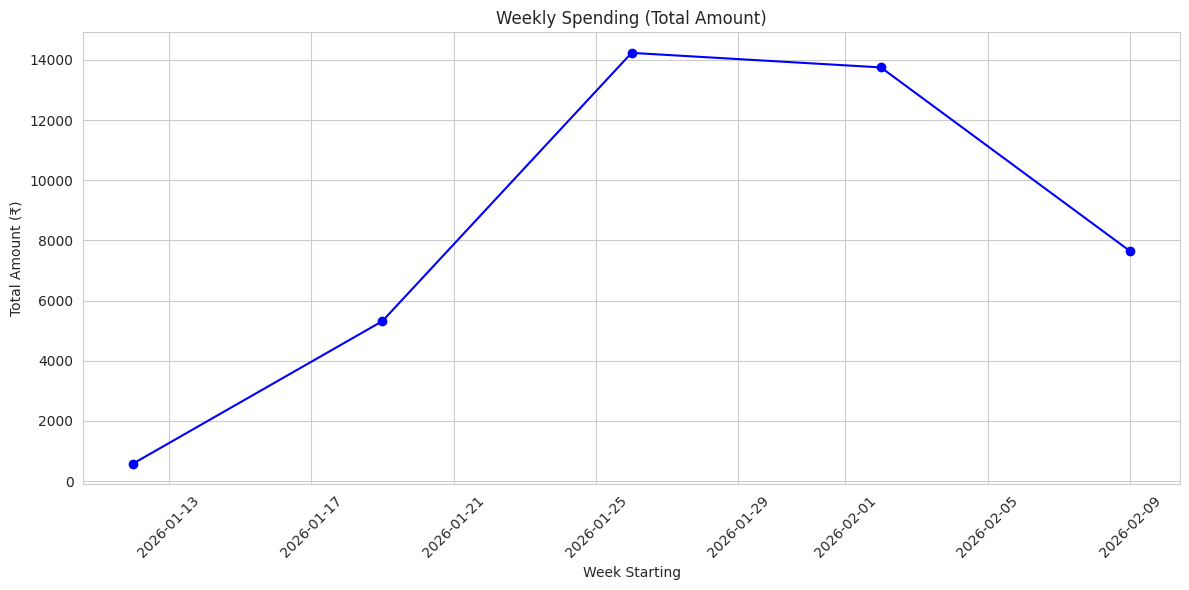

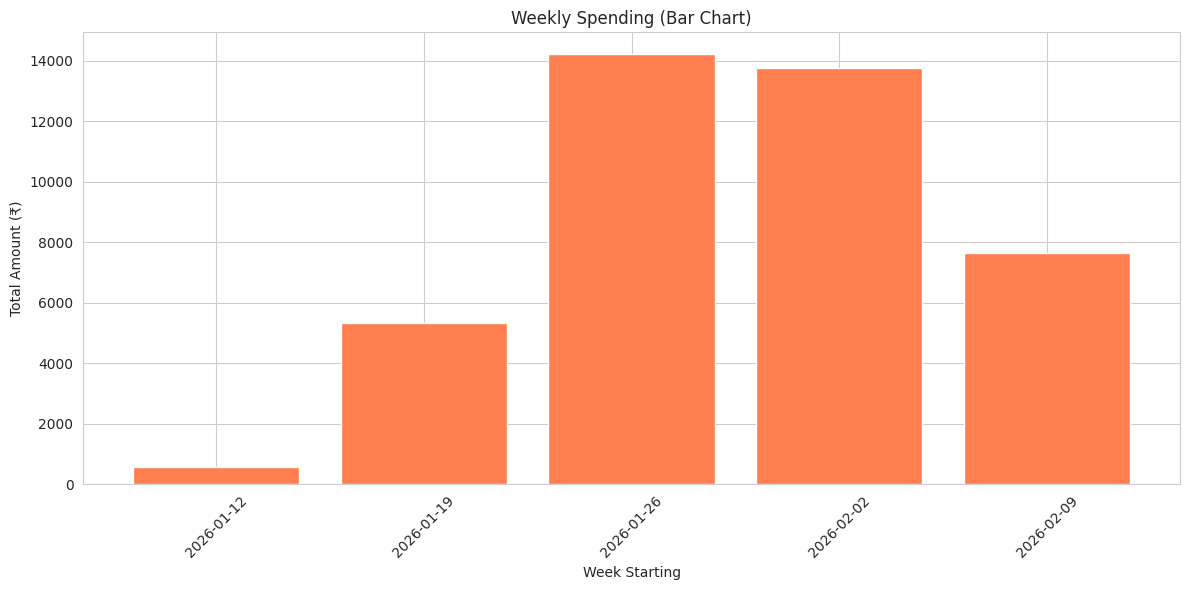


Top recipient by spending each week:
  week_start                              recipient    amount
0 2026-01-12  BP Petrol Pump - Central Auto Service    210.00
1 2026-01-19                        BARBEQUE NATION   2432.88
2 2026-01-26             N.I.T.T.T RESEARCH KOLKATA   6000.00
3 2026-02-02                   CHOWDHURY DRUG HOUSE  10499.00
4 2026-02-09                 R B DIAGNOSTIC Pvt Ltd   2200.00

Weekly summary saved to 'weekly_spending_summary.csv'


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns  # optional, for better styling

# Set style for plots
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# 1. Load the CSV file (adjust filename as needed)
csv_file = "/content/PhonePe_Statement_Jan2026_Feb2026_transactions.csv"  # replace with your file
df = pd.read_csv(csv_file)

# 2. Inspect the data
print("First few rows:")
print(df.head())
print("\nData info:")
print(df.info())

# 3. Convert the 'date' column to datetime
# The date format in the CSV is like "Feb 13, 2026"
df['parsed_date'] = pd.to_datetime(df['date'], format='%b %d, %Y', errors='coerce')

# Check for any parsing errors
if df['parsed_date'].isna().any():
    print(f"Warning: {df['parsed_date'].isna().sum()} dates could not be parsed.")
    # Optionally drop rows with invalid dates
    df = df.dropna(subset=['parsed_date'])

# 4. Add a 'week' column (starting Monday)
df['week_start'] = df['parsed_date'].dt.to_period('W').dt.start_time

# 5. Filter for DEBIT transactions (spending)
spending_df = df[df['type'] == 'DEBIT'].copy()

if spending_df.empty:
    print("No DEBIT transactions found. Check the 'type' column values.")
else:
    # 6. Group by week and sum the amounts
    weekly_spending = spending_df.groupby('week_start')['amount'].agg(['sum', 'count', 'mean']).reset_index()
    weekly_spending.columns = ['week_start', 'total_spent', 'transaction_count', 'average_transaction']

    # Sort by week
    weekly_spending = weekly_spending.sort_values('week_start')

    print("\nWeekly Spending Summary:")
    print(weekly_spending.to_string(index=False))

    # 7. Plot weekly spending
    plt.figure()
    plt.plot(weekly_spending['week_start'], weekly_spending['total_spent'], marker='o', linestyle='-', color='b')
    plt.title('Weekly Spending (Total Amount)')
    plt.xlabel('Week Starting')
    plt.ylabel('Total Amount (₹)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # Optional: Bar chart of weekly spending
    plt.figure()
    plt.bar(weekly_spending['week_start'].astype(str), weekly_spending['total_spent'], color='coral')
    plt.title('Weekly Spending (Bar Chart)')
    plt.xlabel('Week Starting')
    plt.ylabel('Total Amount (₹)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # 8. Optional: Top recipients per week
    top_per_week = spending_df.groupby(['week_start', 'recipient'])['amount'].sum().reset_index()
    top_per_week = top_per_week.sort_values(['week_start', 'amount'], ascending=[True, False])
    print("\nTop recipient by spending each week:")
    print(top_per_week.groupby('week_start').first().reset_index())

# 9. (Optional) Save the weekly summary to CSV
weekly_spending.to_csv('weekly_spending_summary.csv', index=False)
print("\nWeekly summary saved to 'weekly_spending_summary.csv'")

### Time Interval base spending distribution

First few rows:
           date      time                recipient   type  amount  \
0  Feb 01, 2026  08:22 am          HARASHIT MANDAL  DEBIT    20.0   
1  Feb 01, 2026  03:00 pm     Mother Dairy Kolkata  DEBIT    70.0   
2  Feb 01, 2026  06:12 pm  RELIANCE RETAIL LIMITED  DEBIT   852.0   
3  Feb 01, 2026  02:46 pm         GATE 1 COUNTER 3  DEBIT    60.0   
4  Feb 01, 2026  02:42 pm         Priya collection  DEBIT    70.0   

            transaction_id parsed_date  
0  T2602010822013404242026  2026-02-01  
1  T2602011500326222250201  2026-02-01  
2  T2602011812451387722766  2026-02-01  
3  T2602011446018365984401  2026-02-01  
4  T2602011442211164242410  2026-02-01  

Data columns: ['date', 'time', 'recipient', 'type', 'amount', 'transaction_id', 'parsed_date']


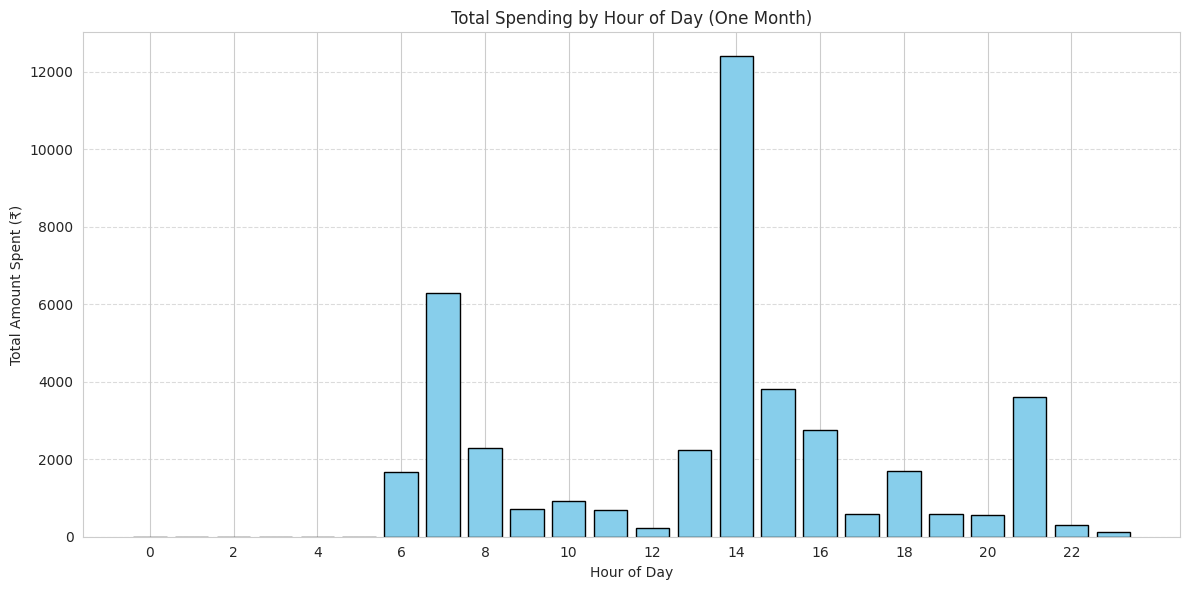

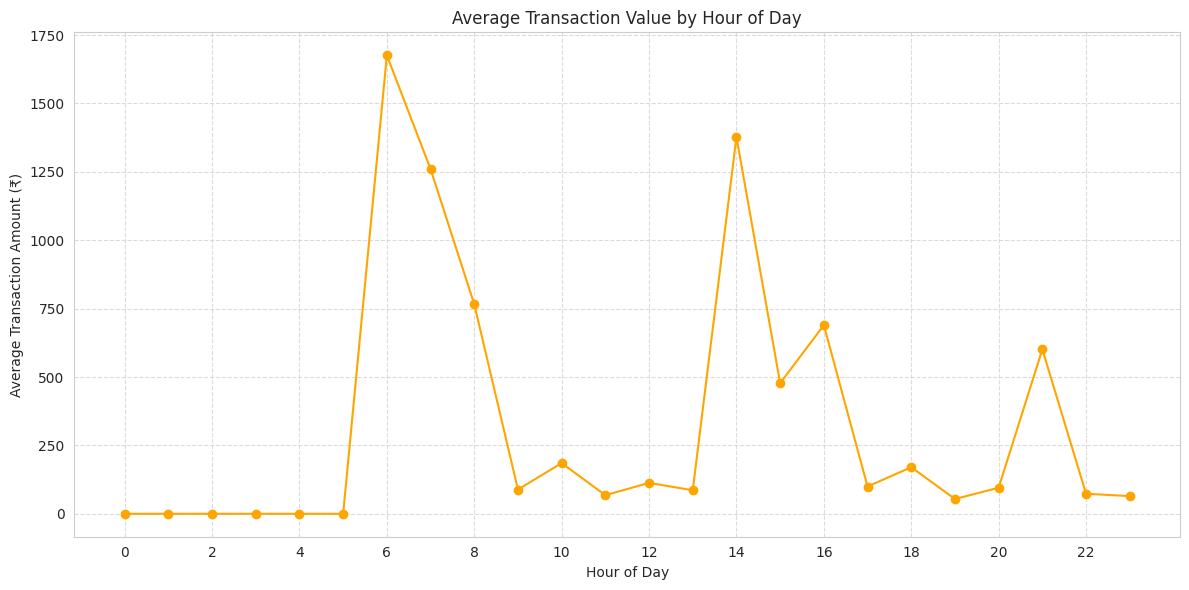


Spending by Hour of Day:
 hour  total_spent  transaction_count  avg_transaction
    0         0.00                  0         0.000000
    1         0.00                  0         0.000000
    2         0.00                  0         0.000000
    3         0.00                  0         0.000000
    4         0.00                  0         0.000000
    5         0.00                  0         0.000000
    6      1676.00                  1      1676.000000
    7      6300.00                  5      1260.000000
    8      2298.00                  3       766.000000
    9       709.00                  8        88.625000
   10       927.00                  5       185.400000
   11       680.00                 10        68.000000
   12       226.00                  2       113.000000
   13      2235.83                 26        85.993462
   14     12395.00                  9      1377.222222
   15      3820.00                  8       477.500000
   16      2758.00                  4  

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Optional: better styling
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# ------------------------------
# 1. Load the CSV file
# ------------------------------
csv_file = "PhonePe_Statement_Jan2026_Feb2026_transactions.csv"  # <-- change to your file
df = pd.read_csv(csv_file)

# Display basic info
print("First few rows:")
print(df.head())
print("\nData columns:", df.columns.tolist())

# ------------------------------
# 2. Prepare datetime and time-of-day
# ------------------------------
# Check if we have both 'date' and 'time' columns
if 'date' not in df.columns:
    raise ValueError("CSV does not contain a 'date' column.")
if 'time' not in df.columns:
    print("Warning: 'time' column not found. Attempting to parse from 'date' (if it contains time).")
    # If 'date' contains both date and time, try to parse it directly.
    # But based on your extractor, time is separate. We'll assume it's missing and raise.
    raise ValueError("Time column is required for this analysis. Please ensure your CSV includes a 'time' column.")

# Convert date to datetime
df['parsed_date'] = pd.to_datetime(df['date'], format='%b %d, %Y', errors='coerce')

# Drop rows with invalid dates
initial_len = len(df)
df = df.dropna(subset=['parsed_date'])
if len(df) < initial_len:
    print(f"Dropped {initial_len - len(df)} rows with invalid dates.")

# Combine date and time to a single timestamp
# The time format in your extractor is like "3:45 PM" or "3:45PM". We'll handle common variations.
def combine_date_time(row):
    try:
        time_str = str(row['time']).strip()
        # Try parsing with various formats
        for fmt in ["%I:%M %p", "%I:%M%p", "%H:%M"]:
            try:
                time_obj = pd.to_datetime(time_str, format=fmt).time()
                return pd.Timestamp.combine(row['parsed_date'].date(), time_obj)
            except:
                continue
        # If all fail, return NaT
        return pd.NaT
    except:
        return pd.NaT

df['timestamp'] = df.apply(combine_date_time, axis=1)
df = df.dropna(subset=['timestamp'])  # drop rows where time parsing failed

# Extract hour of day
df['hour'] = df['timestamp'].dt.hour

# ------------------------------
# 3. Filter for spending (DEBIT)
# ------------------------------
if 'type' in df.columns:
    spending_df = df[df['type'].str.upper().str.contains('DEBIT')].copy()
else:
    # If no type column, assume all are spending? Better to warn.
    print("Warning: No 'type' column found. Assuming all transactions are spending.")
    spending_df = df.copy()

if spending_df.empty:
    print("No spending transactions found. Exiting.")
    exit()

# ------------------------------
# 4. Group by hour and analyze
# ------------------------------
hourly_stats = spending_df.groupby('hour')['amount'].agg(['sum', 'count', 'mean']).reset_index()
hourly_stats.columns = ['hour', 'total_spent', 'transaction_count', 'avg_transaction']

# Ensure all hours 0-23 are present (fill missing with zeros)
hourly_stats = hourly_stats.set_index('hour').reindex(range(24), fill_value=0).reset_index()

# ------------------------------
# 5. Visualize
# ------------------------------
# Bar chart of total spending per hour
plt.figure()
plt.bar(hourly_stats['hour'], hourly_stats['total_spent'], color='skyblue', edgecolor='black')
plt.xlabel('Hour of Day')
plt.ylabel('Total Amount Spent (₹)')
plt.title('Total Spending by Hour of Day (One Month)')
plt.xticks(range(0, 24, 2))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Line plot of average transaction value per hour
plt.figure()
plt.plot(hourly_stats['hour'], hourly_stats['avg_transaction'], marker='o', linestyle='-', color='orange')
plt.xlabel('Hour of Day')
plt.ylabel('Average Transaction Amount (₹)')
plt.title('Average Transaction Value by Hour of Day')
plt.xticks(range(0, 24, 2))
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Optional: Heatmap of spending by hour and day of week? But user asked one-month period, so we can keep simple.

# ------------------------------
# 6. Print summary table
# ------------------------------
print("\nSpending by Hour of Day:")
print(hourly_stats.to_string(index=False))

# Save to CSV for further use
hourly_stats.to_csv('hourly_spending_summary.csv', index=False)
print("\nHourly summary saved to 'hourly_spending_summary.csv'")

In [ ]:
### Categorization of the time
def period_of_day(hour):
    if 5 <= hour < 12: return 'Morning'
    elif 12 <= hour < 17: return 'Afternoon'
    elif 17 <= hour < 21: return 'Evening'
    else: return 'Night'
spending_df['period'] = spending_df['hour'].apply(period_of_day)

First few rows:
           date      time                recipient   type  amount  \
0  Feb 01, 2026  08:22 am          HARASHIT MANDAL  DEBIT    20.0   
1  Feb 01, 2026  03:00 pm     Mother Dairy Kolkata  DEBIT    70.0   
2  Feb 01, 2026  06:12 pm  RELIANCE RETAIL LIMITED  DEBIT   852.0   
3  Feb 01, 2026  02:46 pm         GATE 1 COUNTER 3  DEBIT    60.0   
4  Feb 01, 2026  02:42 pm         Priya collection  DEBIT    70.0   

            transaction_id parsed_date  
0  T2602010822013404242026  2026-02-01  
1  T2602011500326222250201  2026-02-01  
2  T2602011812451387722766  2026-02-01  
3  T2602011446018365984401  2026-02-01  
4  T2602011442211164242410  2026-02-01  

Data columns: ['date', 'time', 'recipient', 'type', 'amount', 'transaction_id', 'parsed_date']

Total transactions: 128

Spending transactions (DEBIT): 126

RECIPIENT ANALYSIS - OVERALL STATISTICS

Top 20 recipients by transaction count:
                            recipient  total_transactions  total_amount   avg_amount

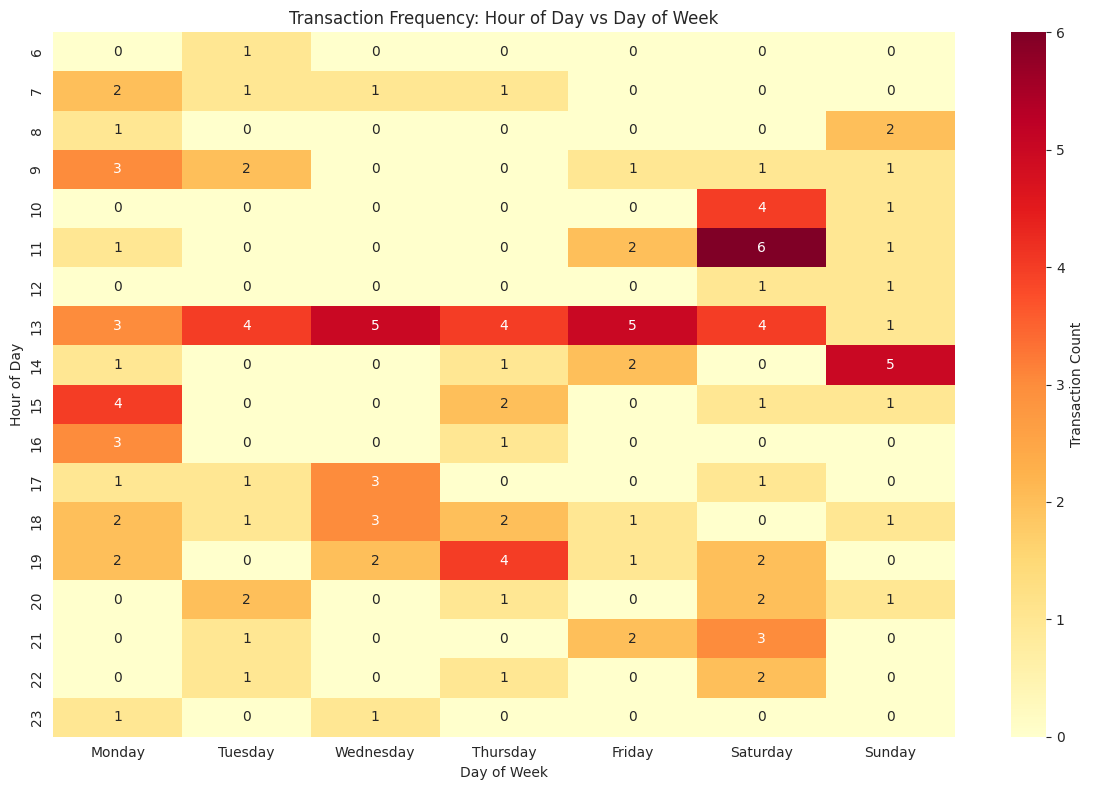

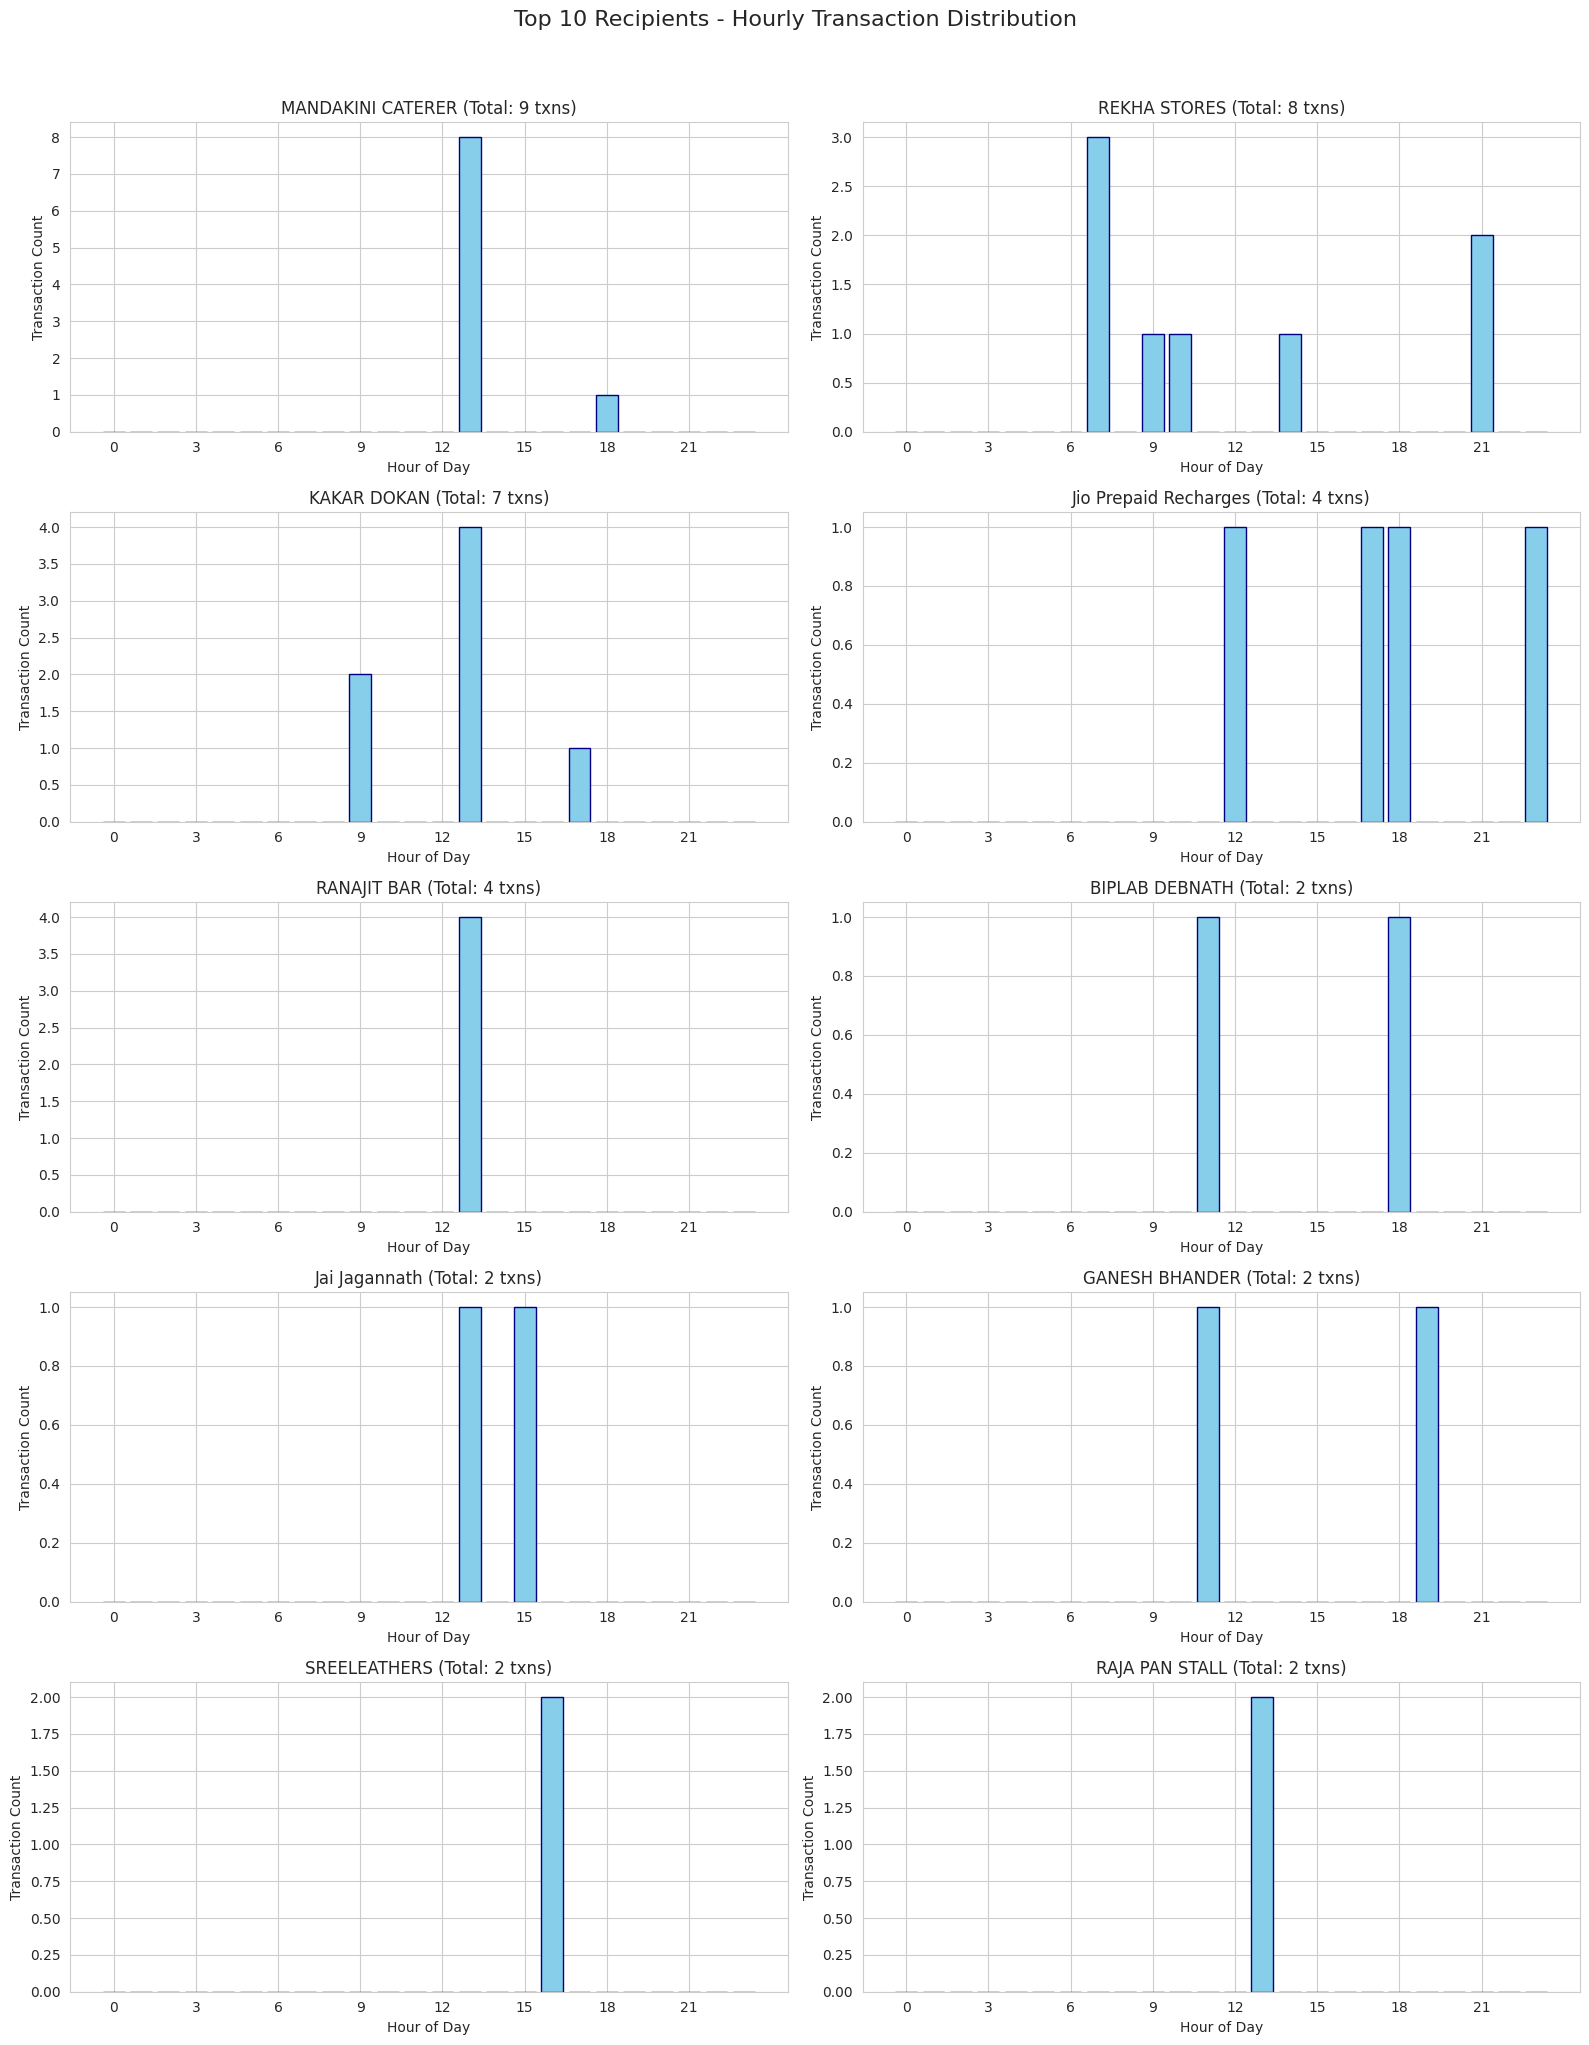

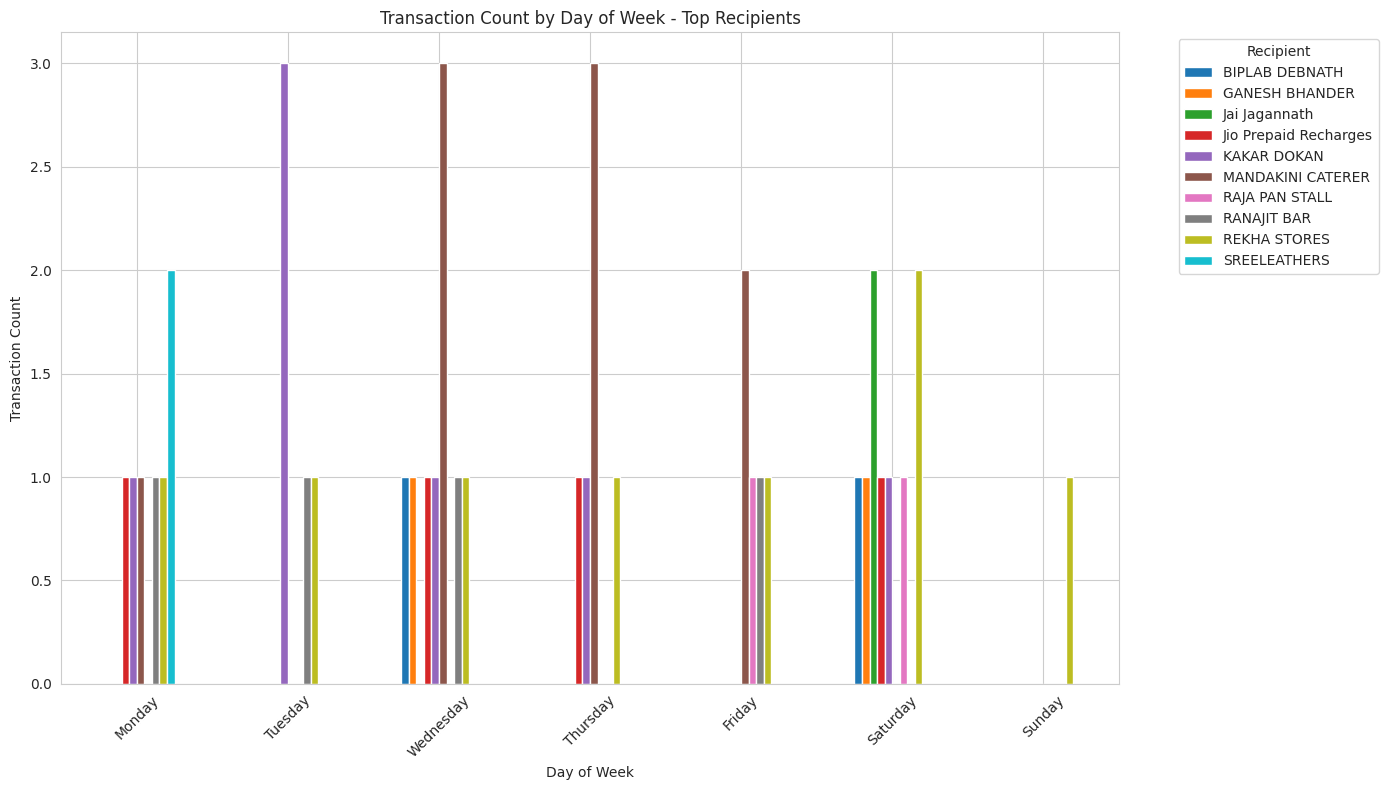


DETAILED RECIPIENT REPORT

📊 MANDAKINI CATERER
  Total Transactions: 9
  Total Amount: ₹525.00
  Average Amount: ₹58.33
  Peak Hour: 13:00 (8 transactions)
  Peak Day: Thursday (3 transactions)
  Most Common Amount Range: (0.0, 100.0]

📊 REKHA STORES
  Total Transactions: 8
  Total Amount: ₹503.00
  Average Amount: ₹62.88
  Peak Hour: 7:00 (3 transactions)
  Peak Day: Saturday (2 transactions)
  Most Common Amount Range: (0.0, 100.0]

📊 KAKAR DOKAN
  Total Transactions: 7
  Total Amount: ₹366.00
  Average Amount: ₹52.29
  Peak Hour: 13:00 (4 transactions)
  Peak Day: Tuesday (3 transactions)
  Most Common Amount Range: (0.0, 100.0]

📊 Jio Prepaid Recharges
  Total Transactions: 4
  Total Amount: ₹106.00
  Average Amount: ₹26.50
  Peak Hour: 17:00 (1 transactions)
  Peak Day: Wednesday (1 transactions)
  Most Common Amount Range: (0.0, 100.0]

📊 RANAJIT BAR
  Total Transactions: 4
  Total Amount: ₹190.00
  Average Amount: ₹47.50
  Peak Hour: 13:00 (4 transactions)
  Peak Day: Monday (1

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Optional: better styling
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 8)

# ------------------------------
# 1. Load the CSV file
# ------------------------------
csv_file = "PhonePe_Statement_Jan2026_Feb2026_transactions.csv"  # <-- change to your file
df = pd.read_csv(csv_file)

print("First few rows:")
print(df.head())
print("\nData columns:", df.columns.tolist())
print(f"\nTotal transactions: {len(df)}")

# ------------------------------
# 2. Prepare datetime and time components
# ------------------------------
# Check for required columns
if 'date' not in df.columns:
    raise ValueError("CSV does not contain a 'date' column.")
if 'recipient' not in df.columns:
    raise ValueError("CSV does not contain a 'recipient' column.")

# Convert date to datetime
df['parsed_date'] = pd.to_datetime(df['date'], format='%b %d, %Y', errors='coerce')

# Drop rows with invalid dates
initial_len = len(df)
df = df.dropna(subset=['parsed_date'])
if len(df) < initial_len:
    print(f"Dropped {initial_len - len(df)} rows with invalid dates.")

# Handle time column if available
if 'time' in df.columns:
    # Combine date and time to a single timestamp
    def combine_date_time(row):
        try:
            time_str = str(row['time']).strip()
            # Try parsing with various formats
            for fmt in ["%I:%M %p", "%I:%M%p", "%H:%M"]:
                try:
                    time_obj = pd.to_datetime(time_str, format=fmt).time()
                    return pd.Timestamp.combine(row['parsed_date'].date(), time_obj)
                except:
                    continue
            # If all fail, use midnight
            return pd.Timestamp.combine(row['parsed_date'].date(), datetime.min.time())
        except:
            return pd.Timestamp.combine(row['parsed_date'].date(), datetime.min.time())

    df['timestamp'] = df.apply(combine_date_time, axis=1)
else:
    # If no time column, set timestamp to midnight
    print("Warning: No 'time' column found. Setting all times to midnight.")
    df['timestamp'] = pd.to_datetime(df['parsed_date'].dt.date)

# Extract time components
df['hour'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.day_name()
df['day_of_week_num'] = df['timestamp'].dt.dayofweek  # Monday=0, Sunday=6
df['date_only'] = df['timestamp'].dt.date

# ------------------------------
# 3. Filter for spending (DEBIT) if type column exists
# ------------------------------
if 'type' in df.columns:
    spending_df = df[df['type'].str.upper().str.contains('DEBIT')].copy()
    print(f"\nSpending transactions (DEBIT): {len(spending_df)}")
else:
    print("Warning: No 'type' column found. Analyzing all transactions.")
    spending_df = df.copy()

if spending_df.empty:
    print("No spending transactions found. Exiting.")
    exit()

# ------------------------------
# 4. Recipient Analysis by Time and Frequency
# ------------------------------

# 4.1 Overall recipient statistics
print("\n" + "="*80)
print("RECIPIENT ANALYSIS - OVERALL STATISTICS")
print("="*80)

recipient_stats = spending_df.groupby('recipient').agg(
    total_transactions=('recipient', 'count'),
    total_amount=('amount', 'sum'),
    avg_amount=('amount', 'mean'),
    min_amount=('amount', 'min'),
    max_amount=('amount', 'max'),
    first_transaction=('timestamp', 'min'),
    last_transaction=('timestamp', 'max')
).reset_index()

# Add frequency per day
def calculate_avg_days_between(row):
    if row['total_transactions'] > 1:
        days_diff = (row['last_transaction'] - row['first_transaction']).days
        return days_diff / (row['total_transactions'] - 1)
    else:
        return float('inf')

recipient_stats['avg_days_between'] = recipient_stats.apply(calculate_avg_days_between, axis=1)

recipient_stats = recipient_stats.sort_values('total_transactions', ascending=False)

print("\nTop 20 recipients by transaction count:")
print(recipient_stats.head(20).to_string(index=False))

# 4.2 Hour of day distribution for each recipient
print("\n" + "="*80)
print("RECIPIENT ANALYSIS - HOURLY DISTRIBUTION")
print("="*80)

# Get top N recipients for detailed analysis
top_n = 10
top_recipients = recipient_stats.head(top_n)['recipient'].tolist()
top_df = spending_df[spending_df['recipient'].isin(top_recipients)]

# Create hour distribution - FIXED VERSION (without fill_value)
# Method 1: Using pivot_table
hour_pivot = pd.pivot_table(
    top_df,
    values='amount',
    index='recipient',
    columns='hour',
    aggfunc='count',
    fill_value=0  # fill_value works in pivot_table
)

# Ensure all hours 0-23 are present
for hour in range(24):
    if hour not in hour_pivot.columns:
        hour_pivot[hour] = 0

# Sort columns
hour_pivot = hour_pivot[sorted(hour_pivot.columns)]

print("\nHourly transaction count for top recipients:")
print(hour_pivot)

# 4.3 Day of week distribution for each recipient
print("\n" + "="*80)
print("RECIPIENT ANALYSIS - DAY OF WEEK DISTRIBUTION")
print("="*80)

# Order days properly
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
top_df['day_of_week'] = pd.Categorical(top_df['day_of_week'], categories=day_order, ordered=True)

# Using pivot_table instead of crosstab
day_pivot = pd.pivot_table(
    top_df,
    values='amount',
    index='recipient',
    columns='day_of_week',
    aggfunc='count',
    fill_value=0
)

print("\nDaily transaction count for top recipients:")
print(day_pivot)

# 4.4 Complete time analysis - pivot table of recipient by hour and day
print("\n" + "="*80)
print("RECIPIENT ANALYSIS - COMPLETE TIME MATRIX")
print("="*80)

# Create a combined time slot (Day + Hour)
top_df['day_hour'] = top_df['day_of_week'].astype(str) + ' ' + top_df['hour'].astype(str) + ':00'

# Pivot table for top recipients
# Limit to avoid too many columns
time_matrix = pd.pivot_table(
    top_df,
    values='amount',
    index='recipient',
    columns='day_hour',
    aggfunc='count',
    fill_value=0
)

print("\nSample of time matrix (first 10 columns):")
print(time_matrix.iloc[:, :min(10, time_matrix.shape[1])])

# ------------------------------
# 5. Visualizations
# ------------------------------

# 5.1 Heatmap - Hour vs Day of Week for all spending
print("\n" + "="*80)
print("GENERATING VISUALIZATIONS...")
print("="*80)

# Create hour-day pivot for all spending - using pivot_table
hour_day_pivot = pd.pivot_table(
    spending_df,
    values='amount',
    index='hour',
    columns='day_of_week',
    aggfunc='count',
    fill_value=0
)

# Reorder columns by day of week
hour_day_pivot = hour_day_pivot[day_order]

plt.figure(figsize=(12, 8))
sns.heatmap(hour_day_pivot, annot=True, fmt='d', cmap='YlOrRd', cbar_kws={'label': 'Transaction Count'})
plt.title('Transaction Frequency: Hour of Day vs Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Hour of Day')
plt.tight_layout()
plt.savefig('hour_day_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# 5.2 Top recipients - hourly distribution bar chart
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(16, 20))
axes = axes.flatten()

for i, recipient in enumerate(top_recipients[:10]):
    if i < len(axes):
        recipient_data = spending_df[spending_df['recipient'] == recipient]
        hour_counts = recipient_data['hour'].value_counts().sort_index()

        # Ensure all hours are represented
        hour_counts_full = pd.Series(0, index=range(24))
        hour_counts_full.update(hour_counts)

        axes[i].bar(hour_counts_full.index, hour_counts_full.values, color='skyblue', edgecolor='navy')
        axes[i].set_title(f'{recipient} (Total: {len(recipient_data)} txns)')
        axes[i].set_xlabel('Hour of Day')
        axes[i].set_ylabel('Transaction Count')
        axes[i].set_xticks(range(0, 24, 3))

# Hide any unused subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Top 10 Recipients - Hourly Transaction Distribution', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('top_recipients_hourly.png', dpi=150, bbox_inches='tight')
plt.show()

# 5.3 Day of week distribution for top recipients
plt.figure(figsize=(14, 8))
day_pivot.T.plot(kind='bar', ax=plt.gca())
plt.title('Transaction Count by Day of Week - Top Recipients')
plt.xlabel('Day of Week')
plt.ylabel('Transaction Count')
plt.legend(title='Recipient', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('top_recipients_dayofweek.png', dpi=150, bbox_inches='tight')
plt.show()

# ------------------------------
# 6. Detailed Recipient Report
# ------------------------------
print("\n" + "="*80)
print("DETAILED RECIPIENT REPORT")
print("="*80)

# For each top recipient, show their peak times
for recipient in top_recipients:
    recipient_data = spending_df[spending_df['recipient'] == recipient]

    print(f"\n📊 {recipient}")
    print(f"  Total Transactions: {len(recipient_data)}")
    print(f"  Total Amount: ₹{recipient_data['amount'].sum():,.2f}")
    print(f"  Average Amount: ₹{recipient_data['amount'].mean():,.2f}")

    # Peak hour
    if not recipient_data.empty:
        hour_counts = recipient_data['hour'].value_counts()
        if not hour_counts.empty:
            peak_hour = hour_counts.idxmax()
            peak_hour_count = hour_counts.max()
            print(f"  Peak Hour: {peak_hour}:00 ({peak_hour_count} transactions)")

        # Peak day
        day_counts = recipient_data['day_of_week'].value_counts()
        if not day_counts.empty:
            peak_day = day_counts.idxmax()
            peak_day_count = day_counts.max()
            print(f"  Peak Day: {peak_day} ({peak_day_count} transactions)")

        # Most common transaction amount range
        amount_ranges = pd.cut(recipient_data['amount'], bins=[0, 100, 500, 1000, 5000, 10000, float('inf')])
        common_range = amount_ranges.value_counts().idxmax()
        print(f"  Most Common Amount Range: {common_range}")

# ------------------------------
# 7. Export results to Excel
# ------------------------------
print("\n" + "="*80)
print("EXPORTING RESULTS...")
print("="*80)

with pd.ExcelWriter('recipient_time_analysis.xlsx', engine='openpyxl') as writer:
    # Sheet 1: Overall recipient statistics
    recipient_stats.to_excel(writer, sheet_name='Recipient_Stats', index=False)

    # Sheet 2: Hourly distribution for top recipients
    hour_pivot.to_excel(writer, sheet_name='Hourly_Distribution')

    # Sheet 3: Day of week distribution
    day_pivot.to_excel(writer, sheet_name='DayOfWeek_Distribution')

    # Sheet 4: Complete time matrix (sample - first 50 columns to avoid huge file)
    time_matrix_sample = time_matrix.iloc[:, :min(50, time_matrix.shape[1])]
    time_matrix_sample.to_excel(writer, sheet_name='Time_Matrix_Sample')

    # Sheet 5: Raw data filtered for top recipients
    top_df.to_excel(writer, sheet_name='Top_Recipients_Data', index=False)

    # Auto-adjust column widths
    for sheet_name in writer.sheets:
        worksheet = writer.sheets[sheet_name]
        for column in worksheet.columns:
            max_length = 0
            col_letter = column[0].column_letter
            for cell in column:
                try:
                    if len(str(cell.value)) > max_length:
                        max_length = len(str(cell.value))
                except:
                    pass
            adjusted_width = min(max_length + 2, 50)
            worksheet.column_dimensions[col_letter].width = adjusted_width

print("✅ Analysis complete!")
print("📊 Visualizations saved as:")
print("   - hour_day_heatmap.png")
print("   - top_recipients_hourly.png")
print("   - top_recipients_dayofweek.png")
print("📈 Excel report saved as: recipient_time_analysis.xlsx")
print("📋 CSV summary saved as: recipient_time_summary.csv")

# Also save a CSV summary
recipient_stats.to_csv('recipient_time_summary.csv', index=False)

### Task 1: Last appearance of all unique recipient with date and amount in the transcation history and tag them with purpose manually in a CSV file.

### Task 2: Use the created CSV file and map each transcation with it's purpose.

### Task 3: Create a Master data file into json format and CSV formate ,which can be updated after each month trascation report has been processed.